<a href="https://colab.research.google.com/github/RashmiChillal/assignment02_BITSoM_BA_2511806/blob/main/%5CC%3A%5CUsers%5CSantosh%5CAssignment-02-Bitsom%5Cpart4-vector-db%5Cembeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers

# New Section

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by 5 wickets",

    # Cooking
    "I cooked pasta with tomato sauce",
    "She baked a chocolate cake in the oven",
    "The recipe requires fresh vegetables and spices",

    # Cybersecurity
    "The system was attacked by a hacker",
    "Strong passwords improve system security",
    "Encryption protects sensitive data",

    # Extra sentence (to make total 10)
    "Firewalls help prevent unauthorized access"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

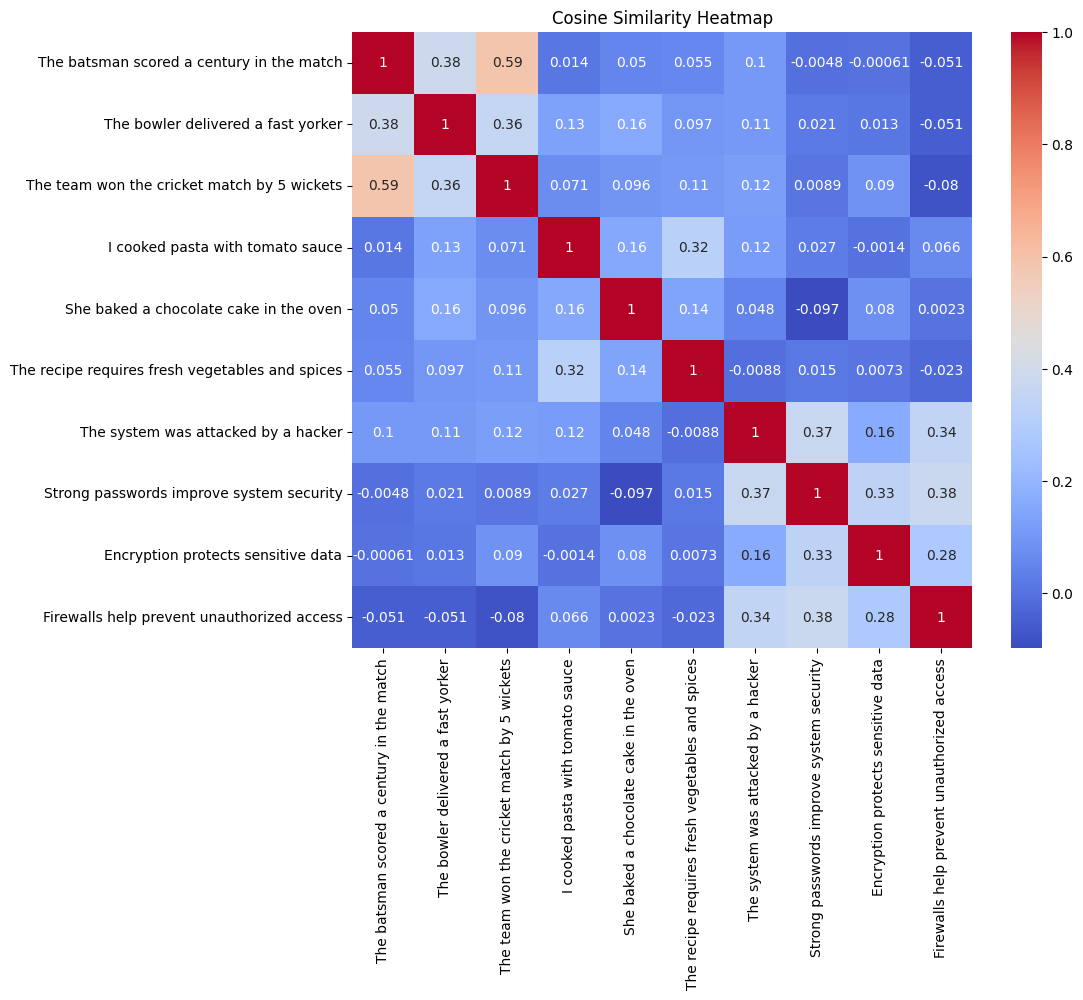

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Heatmap")
plt.show()


In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Sentence: The team won the cricket match by 5 wickets
Similarity Score: 0.7185

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

